In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [2]:
import numpy as np
import random
import os
import matplotlib.pyplot as plt
from itertools import combinations

In [3]:
os.makedirs("dataset", exist_ok=True)

In [4]:
def generate_matrix_with_points(num_points, size=25):
    matrix = np.zeros((size, size), dtype=np.float32)

    all_positions = [(i, j) for i in range(size) for j in range(size)]
    selected_points = random.sample(all_positions, num_points)

    for x, y in selected_points:
        matrix[x, y] = 1.0

    return matrix, selected_points


def manhattan_distance(p1, p2):
    return abs(p1[0] - p2[0]) + abs(p1[1] - p2[1])

In [5]:
def label_problem_A(points):
    distances = []

    for p1, p2 in combinations(points, 2):
        distance = manhattan_distance(p1, p2)
        distances.append(distance)

    return min(distances)

In [6]:
def label_problem_B(points):
    distances = []

    for p1, p2 in combinations(points, 2):
        distance = manhattan_distance(p1, p2)
        distances.append(distance)

    return max(distances)

In [7]:
def label_problem_C(points):
    return len(points)

In [8]:
def label_problem_D(points):
    n = len(points)

    if n % 2 == 0:
        return 0
    else:
        return 1

In [9]:
def label_problem_E(points, size=25):
    n = len(points)

    if n % 2 == 1:
        corner = (0, 0)
    else:
        corner = (size - 1, size - 1)

    distances = []

    for point in points:
        distance = manhattan_distance(point, corner)
        distances.append(distance)

    return min(distances)

In [10]:
def generate_count_based_dataset(problem, samples_per_n, size=25):
    X = []
    y = []

    for n in range(1, 11):
        for _ in range(samples_per_n):
            matrix, points = generate_matrix_with_points(num_points=n, size=size)

            if problem == "C":
                label = label_problem_C(points)
            elif problem == "D":
                label = label_problem_D(points)
            elif problem == "E":
                label = label_problem_E(points, size=size)
            else:
                raise ValueError("problem must be C, D, or E")

            X.append(matrix)
            y.append(label)

    X = np.array(X, dtype=np.float32)
    y = np.array(y, dtype=np.float32)

    return X, y

In [11]:
C_train_X, C_train_y = generate_count_based_dataset("C", samples_per_n=80)
C_test_X, C_test_y = generate_count_based_dataset("C", samples_per_n=20)

np.save("dataset/C_train_X.npy", C_train_X)
np.save("dataset/C_train_y.npy", C_train_y)
np.save("dataset/C_test_X.npy", C_test_X)
np.save("dataset/C_test_y.npy", C_test_y)

print(C_train_X.shape, C_train_y.shape)
print(C_test_X.shape, C_test_y.shape)

(800, 25, 25) (800,)
(200, 25, 25) (200,)


In [12]:
D_train_X, D_train_y = generate_count_based_dataset("D", samples_per_n=80)
D_test_X, D_test_y = generate_count_based_dataset("D", samples_per_n=20)

np.save("dataset/D_train_X.npy", D_train_X)
np.save("dataset/D_train_y.npy", D_train_y)
np.save("dataset/D_test_X.npy", D_test_X)
np.save("dataset/D_test_y.npy", D_test_y)

print(D_train_X.shape, D_train_y.shape)
print(D_test_X.shape, D_test_y.shape)

(800, 25, 25) (800,)
(200, 25, 25) (200,)


In [13]:
D_train_X, D_train_y = generate_count_based_dataset("D", samples_per_n=80)
D_test_X, D_test_y = generate_count_based_dataset("D", samples_per_n=20)

np.save("dataset/D_train_X.npy", D_train_X)
np.save("dataset/D_train_y.npy", D_train_y)
np.save("dataset/D_test_X.npy", D_test_X)
np.save("dataset/D_test_y.npy", D_test_y)

print(D_train_X.shape, D_train_y.shape)
print(D_test_X.shape, D_test_y.shape)

(800, 25, 25) (800,)
(200, 25, 25) (200,)


In [14]:
E_train_X, E_train_y = generate_count_based_dataset("E", samples_per_n=80)
E_test_X, E_test_y = generate_count_based_dataset("E", samples_per_n=20)

np.save("dataset/E_train_X.npy", E_train_X)
np.save("dataset/E_train_y.npy", E_train_y)
np.save("dataset/E_test_X.npy", E_test_X)
np.save("dataset/E_test_y.npy", E_test_y)

print(E_train_X.shape, E_train_y.shape)
print(E_test_X.shape, E_test_y.shape)

(800, 25, 25) (800,)
(200, 25, 25) (200,)


In [15]:
distance_bins = [
    (1, 10),
    (11, 20),
    (21, 30),
    (31, 40),
    (41, 48)
]


def get_bin_index(value, bins):
    for i, (low, high) in enumerate(bins):
        if low <= value <= high:
            return i

    return None

In [16]:
def generate_balanced_distance_dataset(problem, samples_per_bin, size=25):
    X = []
    y = []

    bin_counts = [0] * len(distance_bins)

    while min(bin_counts) < samples_per_bin:
        matrix, points = generate_matrix_with_points(num_points=5, size=size)

        if problem == "A":
            label = label_problem_A(points)
        elif problem == "B":
            label = label_problem_B(points)
        else:
            raise ValueError("problem must be A or B")

        bin_index = get_bin_index(label, distance_bins)

        if bin_index is not None and bin_counts[bin_index] < samples_per_bin:
            X.append(matrix)
            y.append(label)
            bin_counts[bin_index] += 1

    X = np.array(X, dtype=np.float32)
    y = np.array(y, dtype=np.float32)

    return X, y, bin_counts

In [17]:
import numpy as np
import random
import os
import matplotlib.pyplot as plt
from itertools import combinations

os.makedirs("dataset", exist_ok=True)

random.seed(42)
np.random.seed(42)

In [18]:
def generate_matrix_with_points(num_points, size=25):
    matrix = np.zeros((size, size), dtype=np.float32)

    all_positions = [(i, j) for i in range(size) for j in range(size)]
    selected_points = random.sample(all_positions, num_points)

    for x, y in selected_points:
        matrix[x, y] = 1.0

    return matrix, selected_points


def manhattan_distance(p1, p2):
    return abs(p1[0] - p2[0]) + abs(p1[1] - p2[1])


def label_problem_A(points):
    distances = []

    for p1, p2 in combinations(points, 2):
        distances.append(manhattan_distance(p1, p2))

    return min(distances)


def label_problem_B(points):
    distances = []

    for p1, p2 in combinations(points, 2):
        distances.append(manhattan_distance(p1, p2))

    return max(distances)

In [19]:
def generate_pool_for_problem(problem, pool_size=20000, size=25):
    X_pool = []
    y_pool = []

    for _ in range(pool_size):
        matrix, points = generate_matrix_with_points(num_points=5, size=size)

        if problem == "A":
            label = label_problem_A(points)
        elif problem == "B":
            label = label_problem_B(points)
        else:
            raise ValueError("problem must be A or B")

        X_pool.append(matrix)
        y_pool.append(label)

    X_pool = np.array(X_pool, dtype=np.float32)
    y_pool = np.array(y_pool, dtype=np.float32)

    return X_pool, y_pool

In [20]:
def create_balanced_from_pool(X_pool, y_pool, total_samples=800, num_bins=5):
    samples_per_bin = total_samples // num_bins

    sorted_indices = np.argsort(y_pool)
    sorted_y = y_pool[sorted_indices]

    # Split sorted labels into equal-sized clusters
    bin_indices = np.array_split(sorted_indices, num_bins)

    X_balanced = []
    y_balanced = []
    bin_ranges = []

    for indices in bin_indices:
        selected = np.random.choice(indices, size=samples_per_bin, replace=False)

        X_balanced.append(X_pool[selected])
        y_balanced.append(y_pool[selected])

        bin_ranges.append((float(np.min(y_pool[indices])), float(np.max(y_pool[indices]))))

    X_balanced = np.concatenate(X_balanced, axis=0)
    y_balanced = np.concatenate(y_balanced, axis=0)

    # Shuffle final dataset
    shuffle_indices = np.random.permutation(len(y_balanced))
    X_balanced = X_balanced[shuffle_indices]
    y_balanced = y_balanced[shuffle_indices]

    return X_balanced, y_balanced, bin_ranges

In [21]:
A_X_pool, A_y_pool = generate_pool_for_problem(problem="A", pool_size=20000)

A_train_X, A_train_y, A_train_bins = create_balanced_from_pool(
    A_X_pool,
    A_y_pool,
    total_samples=800,
    num_bins=5
)

A_test_X, A_test_y, A_test_bins = create_balanced_from_pool(
    A_X_pool,
    A_y_pool,
    total_samples=200,
    num_bins=5
)

np.save("dataset/A_train_X.npy", A_train_X)
np.save("dataset/A_train_y.npy", A_train_y)
np.save("dataset/A_test_X.npy", A_test_X)
np.save("dataset/A_test_y.npy", A_test_y)

print("A train:", A_train_X.shape, A_train_y.shape)
print("A test:", A_test_X.shape, A_test_y.shape)
print("A bin ranges:", A_train_bins)

A train: (800, 25, 25) (800,)
A test: (200, 25, 25) (200,)
A bin ranges: [(1.0, 3.0), (3.0, 4.0), (4.0, 6.0), (6.0, 7.0), (7.0, 17.0)]


In [22]:
B_X_pool, B_y_pool = generate_pool_for_problem(problem="B", pool_size=20000)

B_train_X, B_train_y, B_train_bins = create_balanced_from_pool(
    B_X_pool,
    B_y_pool,
    total_samples=800,
    num_bins=5
)

B_test_X, B_test_y, B_test_bins = create_balanced_from_pool(
    B_X_pool,
    B_y_pool,
    total_samples=200,
    num_bins=5
)

np.save("dataset/B_train_X.npy", B_train_X)
np.save("dataset/B_train_y.npy", B_train_y)
np.save("dataset/B_test_X.npy", B_test_X)
np.save("dataset/B_test_y.npy", B_test_y)

print("B train:", B_train_X.shape, B_train_y.shape)
print("B test:", B_test_X.shape, B_test_y.shape)
print("B bin ranges:", B_train_bins)

B train: (800, 25, 25) (800,)
B test: (200, 25, 25) (200,)
B bin ranges: [(8.0, 24.0), (24.0, 27.0), (27.0, 30.0), (30.0, 34.0), (34.0, 48.0)]


In [23]:
import numpy as np
import random
import os
import matplotlib.pyplot as plt
from itertools import combinations

os.makedirs("dataset", exist_ok=True)

random.seed(42)
np.random.seed(42)


def generate_matrix_with_points(num_points, size=25):
    matrix = np.zeros((size, size), dtype=np.float32)

    all_positions = [(i, j) for i in range(size) for j in range(size)]
    selected_points = random.sample(all_positions, num_points)

    for x, y in selected_points:
        matrix[x, y] = 1.0

    return matrix, selected_points


def manhattan_distance(p1, p2):
    return abs(p1[0] - p2[0]) + abs(p1[1] - p2[1])


def label_problem_A(points):
    distances = []

    for p1, p2 in combinations(points, 2):
        distances.append(manhattan_distance(p1, p2))

    return min(distances)


def label_problem_B(points):
    distances = []

    for p1, p2 in combinations(points, 2):
        distances.append(manhattan_distance(p1, p2))

    return max(distances)


def generate_pool_for_problem(problem, pool_size=30000, size=25):
    X_pool = []
    y_pool = []

    for _ in range(pool_size):
        matrix, points = generate_matrix_with_points(num_points=5, size=size)

        if problem == "A":
            label = label_problem_A(points)
        elif problem == "B":
            label = label_problem_B(points)
        else:
            raise ValueError("problem must be A or B")

        X_pool.append(matrix)
        y_pool.append(label)

    return np.array(X_pool, dtype=np.float32), np.array(y_pool, dtype=np.float32)

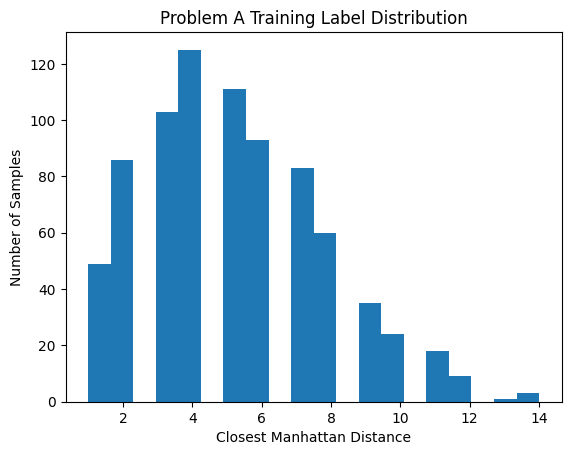

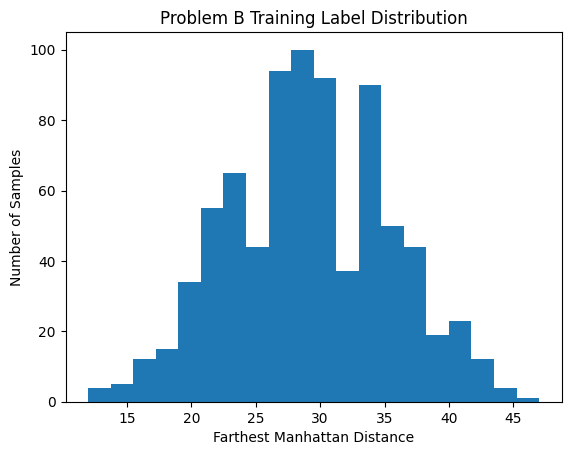

In [24]:
plt.hist(A_train_y, bins=20)
plt.title("Problem A Training Label Distribution")
plt.xlabel("Closest Manhattan Distance")
plt.ylabel("Number of Samples")
plt.show()

plt.hist(B_train_y, bins=20)
plt.title("Problem B Training Label Distribution")
plt.xlabel("Farthest Manhattan Distance")
plt.ylabel("Number of Samples")
plt.show()

In [25]:
def create_balanced_from_pool(X_pool, y_pool, total_samples=800, num_bins=5):
    samples_per_bin = total_samples // num_bins

    sorted_indices = np.argsort(y_pool)

    bin_indices = np.array_split(sorted_indices, num_bins)

    X_balanced = []
    y_balanced = []
    bin_ranges = []
    bin_counts = []

    for indices in bin_indices:
        if len(indices) < samples_per_bin:
            raise ValueError("Pool is too small for this bin. Increase pool_size.")

        selected = np.random.choice(indices, size=samples_per_bin, replace=False)

        X_balanced.append(X_pool[selected])
        y_balanced.append(y_pool[selected])

        bin_ranges.append((int(np.min(y_pool[indices])), int(np.max(y_pool[indices]))))
        bin_counts.append(len(selected))

    X_balanced = np.concatenate(X_balanced, axis=0)
    y_balanced = np.concatenate(y_balanced, axis=0)

    shuffle_indices = np.random.permutation(len(y_balanced))

    return X_balanced[shuffle_indices], y_balanced[shuffle_indices], bin_ranges, bin_counts

In [26]:
A_train_pool_X, A_train_pool_y = generate_pool_for_problem(
    problem="A",
    pool_size=30000
)

A_test_pool_X, A_test_pool_y = generate_pool_for_problem(
    problem="A",
    pool_size=10000
)

A_train_X, A_train_y, A_train_bins, A_train_bin_counts = create_balanced_from_pool(
    A_train_pool_X,
    A_train_pool_y,
    total_samples=800,
    num_bins=5
)

A_test_X, A_test_y, A_test_bins, A_test_bin_counts = create_balanced_from_pool(
    A_test_pool_X,
    A_test_pool_y,
    total_samples=200,
    num_bins=5
)

np.save("dataset/A_train_X.npy", A_train_X)
np.save("dataset/A_train_y.npy", A_train_y)
np.save("dataset/A_test_X.npy", A_test_X)
np.save("dataset/A_test_y.npy", A_test_y)

print("A train:", A_train_X.shape, A_train_y.shape)
print("A test:", A_test_X.shape, A_test_y.shape)
print("A train bin ranges:", A_train_bins)
print("A train bin counts:", A_train_bin_counts)
print("A test bin ranges:", A_test_bins)
print("A test bin counts:", A_test_bin_counts)

A train: (800, 25, 25) (800,)
A test: (200, 25, 25) (200,)
A train bin ranges: [(1, 3), (3, 4), (4, 6), (6, 7), (7, 17)]
A train bin counts: [160, 160, 160, 160, 160]
A test bin ranges: [(1, 3), (3, 4), (4, 6), (6, 7), (7, 16)]
A test bin counts: [40, 40, 40, 40, 40]


In [27]:
B_train_pool_X, B_train_pool_y = generate_pool_for_problem(
    problem="B",
    pool_size=30000
)

B_test_pool_X, B_test_pool_y = generate_pool_for_problem(
    problem="B",
    pool_size=10000
)

B_train_X, B_train_y, B_train_bins, B_train_bin_counts = create_balanced_from_pool(
    B_train_pool_X,
    B_train_pool_y,
    total_samples=800,
    num_bins=5
)

B_test_X, B_test_y, B_test_bins, B_test_bin_counts = create_balanced_from_pool(
    B_test_pool_X,
    B_test_pool_y,
    total_samples=200,
    num_bins=5
)

np.save("dataset/B_train_X.npy", B_train_X)
np.save("dataset/B_train_y.npy", B_train_y)
np.save("dataset/B_test_X.npy", B_test_X)
np.save("dataset/B_test_y.npy", B_test_y)

print("B train:", B_train_X.shape, B_train_y.shape)
print("B test:", B_test_X.shape, B_test_y.shape)
print("B train bin ranges:", B_train_bins)
print("B train bin counts:", B_train_bin_counts)
print("B test bin ranges:", B_test_bins)
print("B test bin counts:", B_test_bin_counts)

B train: (800, 25, 25) (800,)
B test: (200, 25, 25) (200,)
B train bin ranges: [(7, 24), (24, 27), (27, 30), (30, 34), (34, 48)]
B train bin counts: [160, 160, 160, 160, 160]
B test bin ranges: [(7, 24), (24, 27), (27, 30), (30, 34), (34, 48)]
B test bin counts: [40, 40, 40, 40, 40]


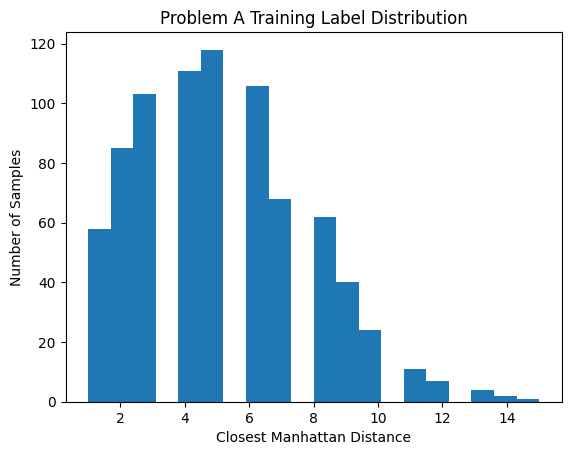

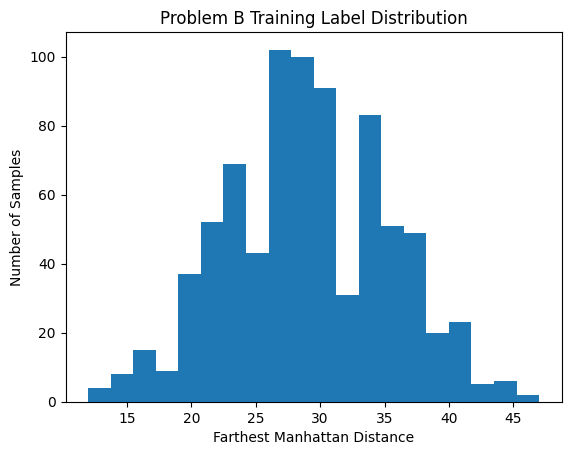

In [28]:
plt.hist(A_train_y, bins=20)
plt.title("Problem A Training Label Distribution")
plt.xlabel("Closest Manhattan Distance")
plt.ylabel("Number of Samples")
plt.show()

plt.hist(B_train_y, bins=20)
plt.title("Problem B Training Label Distribution")
plt.xlabel("Farthest Manhattan Distance")
plt.ylabel("Number of Samples")
plt.show()

In [29]:
print("A train bin counts:", A_train_bin_counts)
print("A test bin counts:", A_test_bin_counts)
print("B train bin counts:", B_train_bin_counts)
print("B test bin counts:", B_test_bin_counts)

A train bin counts: [160, 160, 160, 160, 160]
A test bin counts: [40, 40, 40, 40, 40]
B train bin counts: [160, 160, 160, 160, 160]
B test bin counts: [40, 40, 40, 40, 40]


In [30]:
import os

os.makedirs("figures", exist_ok=True)

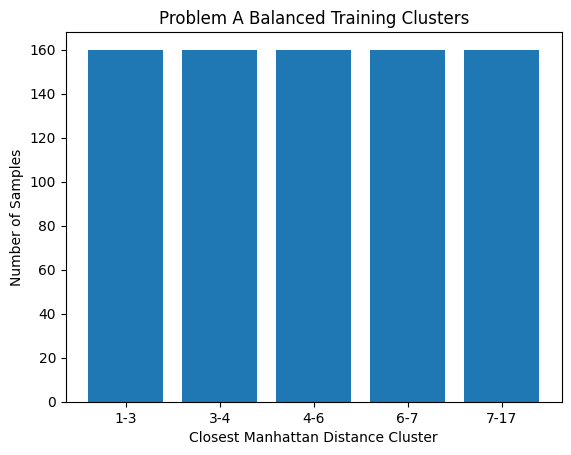

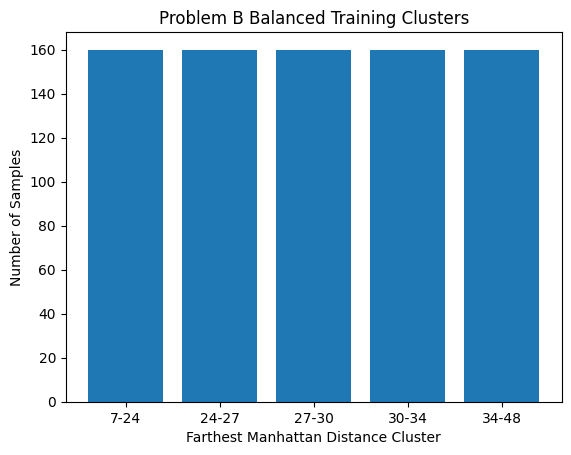

In [31]:
plt.bar(
    [f"{low}-{high}" for low, high in A_train_bins],
    A_train_bin_counts
)
plt.title("Problem A Balanced Training Clusters")
plt.xlabel("Closest Manhattan Distance Cluster")
plt.ylabel("Number of Samples")
plt.savefig("figures/A_train_clusters.png", dpi=300, bbox_inches="tight")
plt.show()

plt.bar(
    [f"{low}-{high}" for low, high in B_train_bins],
    B_train_bin_counts
)
plt.title("Problem B Balanced Training Clusters")
plt.xlabel("Farthest Manhattan Distance Cluster")
plt.ylabel("Number of Samples")
plt.savefig("figures/B_train_clusters.png", dpi=300, bbox_inches="tight")
plt.show()

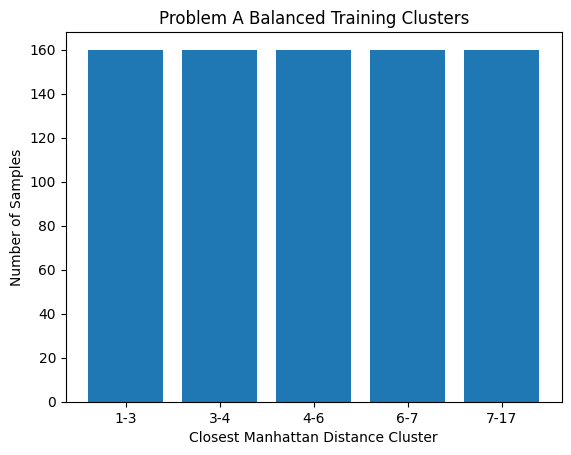

In [32]:
plt.bar(
    [f"{low}-{high}" for low, high in A_train_bins],
    A_train_bin_counts
)
plt.title("Problem A Balanced Training Clusters")
plt.xlabel("Closest Manhattan Distance Cluster")
plt.ylabel("Number of Samples")
plt.savefig("figures/A_train_clusters.png", dpi=300, bbox_inches="tight")
plt.show()

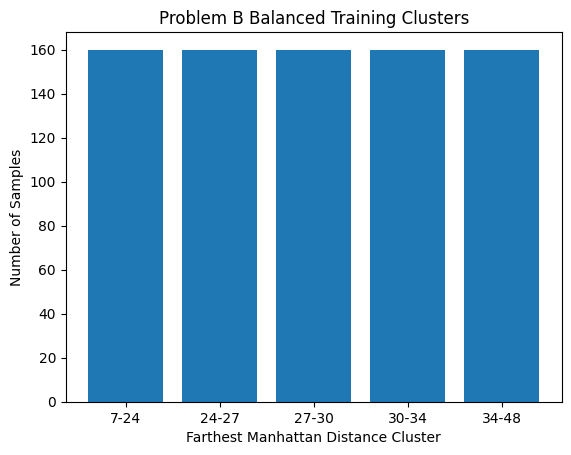

In [33]:
plt.bar(
    [f"{low}-{high}" for low, high in B_train_bins],
    B_train_bin_counts
)
plt.title("Problem B Balanced Training Clusters")
plt.xlabel("Farthest Manhattan Distance Cluster")
plt.ylabel("Number of Samples")
plt.savefig("figures/B_train_clusters.png", dpi=300, bbox_inches="tight")
plt.show()

In [34]:
def label_problem_C(points):
    return len(points)


def label_problem_D(points):
    n = len(points)

    if n % 2 == 0:
        return 0   # even
    else:
        return 1   # odd


def label_problem_E(points, size=25):
    n = len(points)

    if n % 2 == 1:
        corner = (0, 0)
    else:
        corner = (size - 1, size - 1)

    distances = []

    for point in points:
        distances.append(manhattan_distance(point, corner))

    return min(distances)

In [35]:
def generate_count_based_dataset(problem, samples_per_n, size=25):
    X = []
    y = []
    n_values = []

    for n in range(1, 11):
        for _ in range(samples_per_n):
            matrix, points = generate_matrix_with_points(num_points=n, size=size)

            if problem == "C":
                label = label_problem_C(points)
            elif problem == "D":
                label = label_problem_D(points)
            elif problem == "E":
                label = label_problem_E(points, size=size)
            else:
                raise ValueError("problem must be C, D, or E")

            X.append(matrix)
            y.append(label)
            n_values.append(n)

    X = np.array(X, dtype=np.float32)
    y = np.array(y, dtype=np.float32)
    n_values = np.array(n_values, dtype=np.int64)

    shuffle_indices = np.random.permutation(len(y))

    return X[shuffle_indices], y[shuffle_indices], n_values[shuffle_indices]

In [36]:
C_train_X, C_train_y, C_train_n = generate_count_based_dataset("C", samples_per_n=80)
C_test_X, C_test_y, C_test_n = generate_count_based_dataset("C", samples_per_n=20)

np.save("dataset/C_train_X.npy", C_train_X)
np.save("dataset/C_train_y.npy", C_train_y)
np.save("dataset/C_test_X.npy", C_test_X)
np.save("dataset/C_test_y.npy", C_test_y)

print("C train:", C_train_X.shape, C_train_y.shape)
print("C test:", C_test_X.shape, C_test_y.shape)

C train: (800, 25, 25) (800,)
C test: (200, 25, 25) (200,)


In [37]:
D_train_X, D_train_y, D_train_n = generate_count_based_dataset("D", samples_per_n=80)
D_test_X, D_test_y, D_test_n = generate_count_based_dataset("D", samples_per_n=20)

np.save("dataset/D_train_X.npy", D_train_X)
np.save("dataset/D_train_y.npy", D_train_y)
np.save("dataset/D_test_X.npy", D_test_X)
np.save("dataset/D_test_y.npy", D_test_y)

print("D train:", D_train_X.shape, D_train_y.shape)
print("D test:", D_test_X.shape, D_test_y.shape)

D train: (800, 25, 25) (800,)
D test: (200, 25, 25) (200,)


In [38]:
E_train_X, E_train_y, E_train_n = generate_count_based_dataset("E", samples_per_n=80)
E_test_X, E_test_y, E_test_n = generate_count_based_dataset("E", samples_per_n=20)

np.save("dataset/E_train_X.npy", E_train_X)
np.save("dataset/E_train_y.npy", E_train_y)
np.save("dataset/E_test_X.npy", E_test_X)
np.save("dataset/E_test_y.npy", E_test_y)

print("E train:", E_train_X.shape, E_train_y.shape)
print("E test:", E_test_X.shape, E_test_y.shape)

E train: (800, 25, 25) (800,)
E test: (200, 25, 25) (200,)


In [39]:
unique, counts = np.unique(C_train_y, return_counts=True)
print("C train distribution:", dict(zip(unique, counts)))

unique, counts = np.unique(C_test_y, return_counts=True)
print("C test distribution:", dict(zip(unique, counts)))

C train distribution: {np.float32(1.0): np.int64(80), np.float32(2.0): np.int64(80), np.float32(3.0): np.int64(80), np.float32(4.0): np.int64(80), np.float32(5.0): np.int64(80), np.float32(6.0): np.int64(80), np.float32(7.0): np.int64(80), np.float32(8.0): np.int64(80), np.float32(9.0): np.int64(80), np.float32(10.0): np.int64(80)}
C test distribution: {np.float32(1.0): np.int64(20), np.float32(2.0): np.int64(20), np.float32(3.0): np.int64(20), np.float32(4.0): np.int64(20), np.float32(5.0): np.int64(20), np.float32(6.0): np.int64(20), np.float32(7.0): np.int64(20), np.float32(8.0): np.int64(20), np.float32(9.0): np.int64(20), np.float32(10.0): np.int64(20)}


In [40]:
unique, counts = np.unique(D_train_y, return_counts=True)
print("D train distribution:", dict(zip(unique, counts)))

unique, counts = np.unique(D_test_y, return_counts=True)
print("D test distribution:", dict(zip(unique, counts)))

D train distribution: {np.float32(0.0): np.int64(400), np.float32(1.0): np.int64(400)}
D test distribution: {np.float32(0.0): np.int64(100), np.float32(1.0): np.int64(100)}


In [41]:
unique, counts = np.unique(E_train_n, return_counts=True)
print("E train N distribution:", dict(zip(unique, counts)))

unique, counts = np.unique(E_test_n, return_counts=True)
print("E test N distribution:", dict(zip(unique, counts)))

E train N distribution: {np.int64(1): np.int64(80), np.int64(2): np.int64(80), np.int64(3): np.int64(80), np.int64(4): np.int64(80), np.int64(5): np.int64(80), np.int64(6): np.int64(80), np.int64(7): np.int64(80), np.int64(8): np.int64(80), np.int64(9): np.int64(80), np.int64(10): np.int64(80)}
E test N distribution: {np.int64(1): np.int64(20), np.int64(2): np.int64(20), np.int64(3): np.int64(20), np.int64(4): np.int64(20), np.int64(5): np.int64(20), np.int64(6): np.int64(20), np.int64(7): np.int64(20), np.int64(8): np.int64(20), np.int64(9): np.int64(20), np.int64(10): np.int64(20)}


In [42]:
import os
import numpy as np

files = [
    "A_train_X.npy", "A_train_y.npy", "A_test_X.npy", "A_test_y.npy",
    "B_train_X.npy", "B_train_y.npy", "B_test_X.npy", "B_test_y.npy",
    "C_train_X.npy", "C_train_y.npy", "C_test_X.npy", "C_test_y.npy",
    "D_train_X.npy", "D_train_y.npy", "D_test_X.npy", "D_test_y.npy",
    "E_train_X.npy", "E_train_y.npy", "E_test_X.npy", "E_test_y.npy"
]

for file in files:
    path = "dataset/" + file
    
    if os.path.exists(path):
        arr = np.load(path)
        print(file, ":", arr.shape)
    else:
        print(file, ": MISSING")

A_train_X.npy : (800, 25, 25)
A_train_y.npy : (800,)
A_test_X.npy : (200, 25, 25)
A_test_y.npy : (200,)
B_train_X.npy : (800, 25, 25)
B_train_y.npy : (800,)
B_test_X.npy : (200, 25, 25)
B_test_y.npy : (200,)
C_train_X.npy : (800, 25, 25)
C_train_y.npy : (800,)
C_test_X.npy : (200, 25, 25)
C_test_y.npy : (200,)
D_train_X.npy : (800, 25, 25)
D_train_y.npy : (800,)
D_test_X.npy : (200, 25, 25)
D_test_y.npy : (200,)
E_train_X.npy : (800, 25, 25)
E_train_y.npy : (800,)
E_test_X.npy : (200, 25, 25)
E_test_y.npy : (200,)


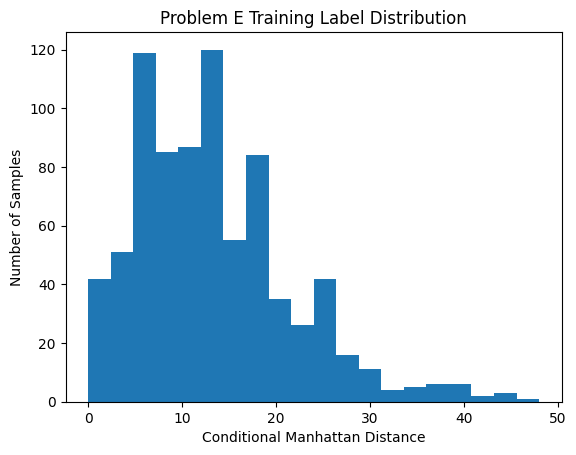

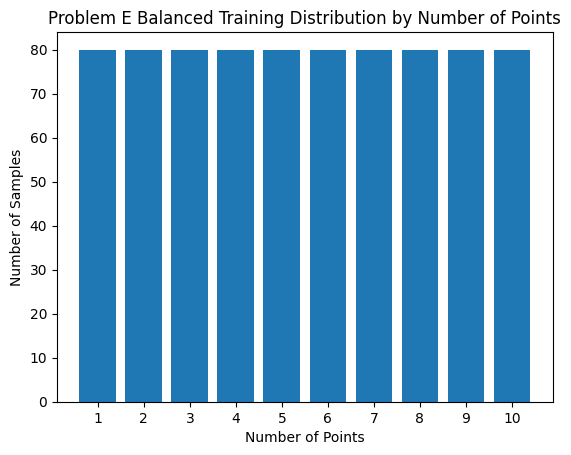

In [43]:
plt.hist(E_train_y, bins=20)
plt.title("Problem E Training Label Distribution")
plt.xlabel("Conditional Manhattan Distance")
plt.ylabel("Number of Samples")
plt.savefig("figures/E_train_histogram.png", dpi=300, bbox_inches="tight")
plt.show()

plt.bar(
    [str(i) for i in range(1, 11)],
    [80] * 10
)
plt.title("Problem E Balanced Training Distribution by Number of Points")
plt.xlabel("Number of Points")
plt.ylabel("Number of Samples")
plt.savefig("figures/E_train_N_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

In [44]:
import os
import numpy as np

files = [
    "A_train_X.npy", "A_train_y.npy", "A_test_X.npy", "A_test_y.npy",
    "B_train_X.npy", "B_train_y.npy", "B_test_X.npy", "B_test_y.npy",
    "C_train_X.npy", "C_train_y.npy", "C_test_X.npy", "C_test_y.npy",
    "D_train_X.npy", "D_train_y.npy", "D_test_X.npy", "D_test_y.npy",
    "E_train_X.npy", "E_train_y.npy", "E_test_X.npy", "E_test_y.npy"
]

for file in files:
    path = "dataset/" + file

    if os.path.exists(path):
        arr = np.load(path)
        print(file, ":", arr.shape)
    else:
        print(file, ": MISSING")

A_train_X.npy : (800, 25, 25)
A_train_y.npy : (800,)
A_test_X.npy : (200, 25, 25)
A_test_y.npy : (200,)
B_train_X.npy : (800, 25, 25)
B_train_y.npy : (800,)
B_test_X.npy : (200, 25, 25)
B_test_y.npy : (200,)
C_train_X.npy : (800, 25, 25)
C_train_y.npy : (800,)
C_test_X.npy : (200, 25, 25)
C_test_y.npy : (200,)
D_train_X.npy : (800, 25, 25)
D_train_y.npy : (800,)
D_test_X.npy : (200, 25, 25)
D_test_y.npy : (200,)
E_train_X.npy : (800, 25, 25)
E_train_y.npy : (800,)
E_test_X.npy : (200, 25, 25)
E_test_y.npy : (200,)


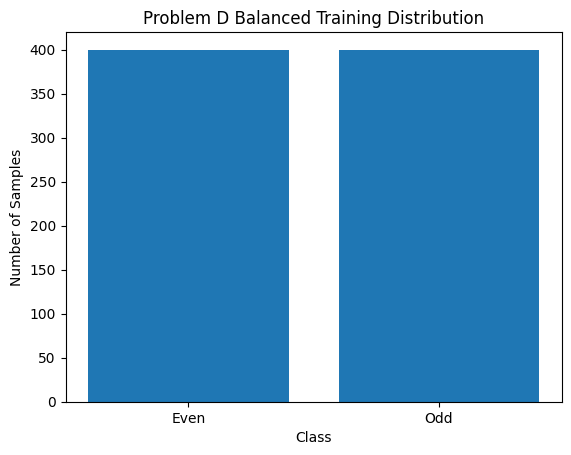

In [45]:
unique_train, counts_train = np.unique(D_train_y, return_counts=True)

labels = []
counts = []

for value, count in zip(unique_train, counts_train):
    if value == 0:
        labels.append("Even")
    else:
        labels.append("Odd")
    counts.append(count)

plt.figure()
plt.bar(labels, counts)
plt.title("Problem D Balanced Training Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Samples")
plt.savefig("figures/D_train_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

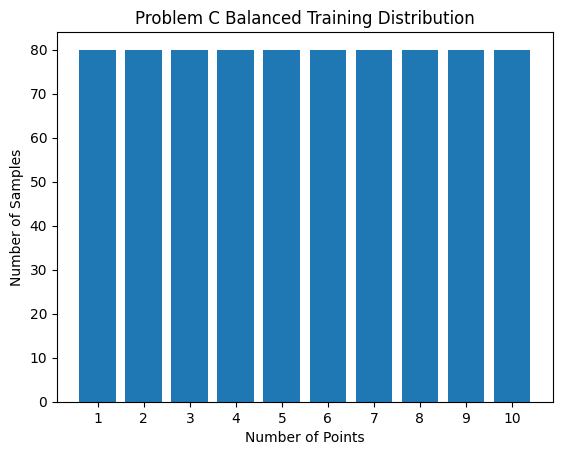

In [46]:
unique_train, counts_train = np.unique(C_train_y, return_counts=True)

plt.figure()
plt.bar([str(int(x)) for x in unique_train], counts_train)
plt.title("Problem C Balanced Training Distribution")
plt.xlabel("Number of Points")
plt.ylabel("Number of Samples")
plt.savefig("figures/C_train_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

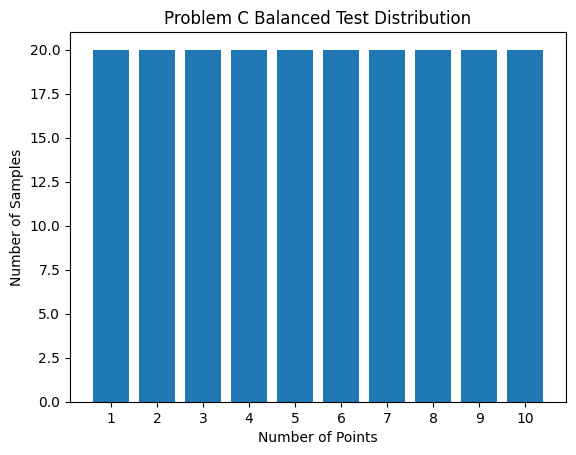

In [47]:
unique_test, counts_test = np.unique(C_test_y, return_counts=True)

plt.figure()
plt.bar([str(int(x)) for x in unique_test], counts_test)
plt.title("Problem C Balanced Test Distribution")
plt.xlabel("Number of Points")
plt.ylabel("Number of Samples")
plt.savefig("figures/C_test_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

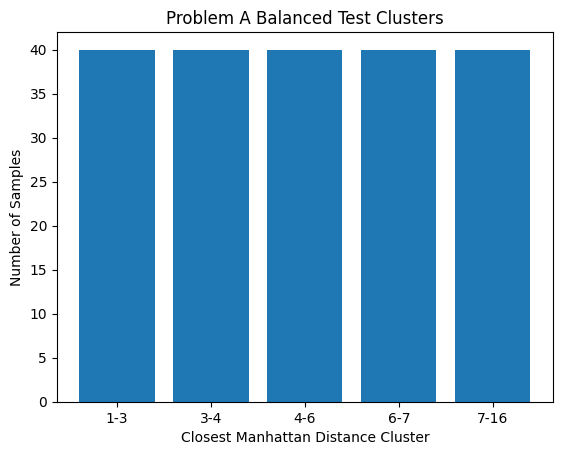

In [48]:
plt.figure()
plt.bar(
    [f"{low}-{high}" for low, high in A_test_bins],
    A_test_bin_counts
)
plt.title("Problem A Balanced Test Clusters")
plt.xlabel("Closest Manhattan Distance Cluster")
plt.ylabel("Number of Samples")
plt.savefig("figures/A_test_clusters.png", dpi=300, bbox_inches="tight")
plt.show()

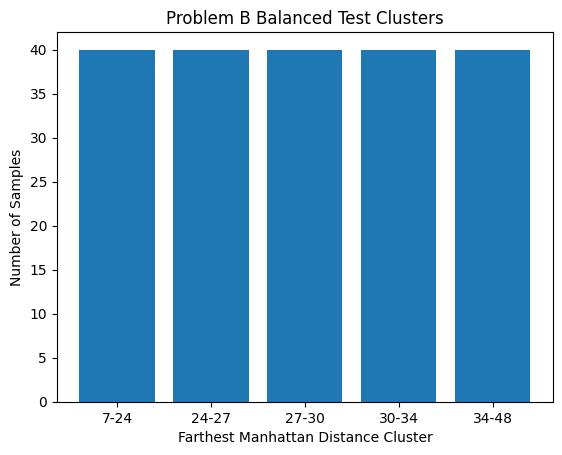

In [49]:
plt.figure()
plt.bar(
    [f"{low}-{high}" for low, high in B_test_bins],
    B_test_bin_counts
)
plt.title("Problem B Balanced Test Clusters")
plt.xlabel("Farthest Manhattan Distance Cluster")
plt.ylabel("Number of Samples")
plt.savefig("figures/B_test_clusters.png", dpi=300, bbox_inches="tight")
plt.show()

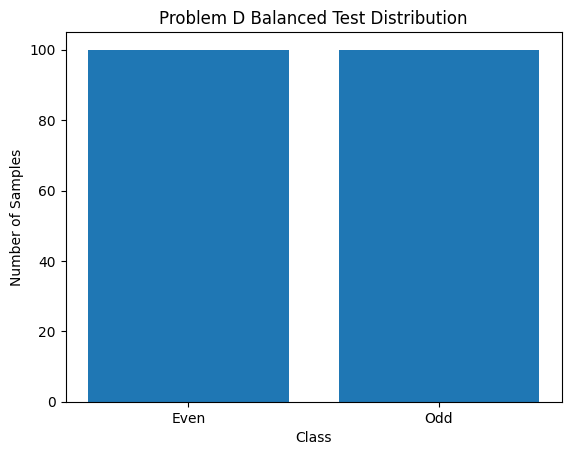

In [50]:
D_test_y = np.load("dataset/D_test_y.npy")

unique_test, counts_test = np.unique(D_test_y, return_counts=True)

labels = []
counts = []

for value, count in zip(unique_test, counts_test):
    if value == 0:
        labels.append("Even")
    else:
        labels.append("Odd")
    counts.append(count)

plt.figure()
plt.bar(labels, counts)
plt.title("Problem D Balanced Test Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Samples")
plt.savefig("figures/D_test_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

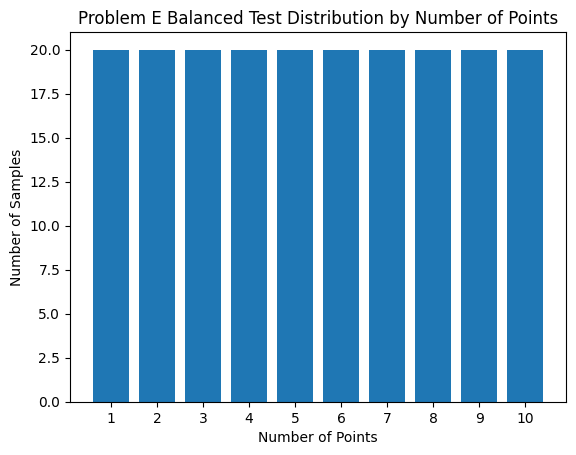

In [51]:
plt.figure()
plt.bar(
    [str(i) for i in range(1, 11)],
    [20] * 10
)
plt.title("Problem E Balanced Test Distribution by Number of Points")
plt.xlabel("Number of Points")
plt.ylabel("Number of Samples")
plt.savefig("figures/E_test_N_distribution.png", dpi=300, bbox_inches="tight")
plt.show()